# Tests for `vertical_helpers` (the LLC4320 vertical axis)

This notebook demonstrates the unit tests in
`tests/test_vertical_helpers.py` for
`src/dbof/preprocessing/vertical_helpers.py` — the helpers that manage
the vertical axis of LLC4320 depth diagnostics: finding the vertical
dimension, converting the native depth coordinate, choosing the layer
thickness, and the reductions built on those (vertical derivative,
select-at-depth, mixed-layer mean).

## ⚠️ Sign convention: depth is POSITIVE-DOWNWARD in dbof

MITgcm/ECCO store the vertical coordinate `Z` **negative below the
surface** (negative-upward). `_get_depth_coord` **flips this to
positive-downward depth** (0 at the surface, increasing with depth),
and every depth used downstream in dbof (mixed-layer comparisons,
nearest-level selection, vertical derivatives) follows that
positive-down convention. **This is the opposite of what other
ECCO/MITgcm tooling exposes** — if you mix dbof depths with other
packages, convert explicitly. The helper now emits a `UserWarning`
every time it applies the flip, so the conversion is never silent
(demonstrated in Section 2).

## Vertical domain of the DBOF store

The DBOF LLC4320 store spans the **upper ocean only**: 51 levels with
cell centres from 0.55 m to 945.6 m (interfaces down to 968.6 m).
Figures below max out near ~950 m because that **is** the DBOF domain —
not a plotting error. The full LLC4320 model has 90 levels to ~7 km;
DBOF keeps the upper-ocean subset used for training.

## Definitions (all in metres)

| symbol | meaning |
|---|---|
| `Z` | native depth of **tracer-cell centres** (negative-up, dim `k`) |
| `Zl` | depth of the **upper interface** of each cell (W points, dim `k_l`) |
| `Zp1` | all `nk+1` **cell interfaces** (dim `k_p1`) |
| `drF` | **vertical thickness of each tracer cell**: `drF[k] = |Zp1[k+1] − Zp1[k]|`; used as the weight in thickness-weighted vertical means |

A **"linear profile"** below means a field that varies linearly with
depth, `f(z) = slope · z` — a straight line in the `f`–`z` plane.
Finite differences are exact for such a field, which gives the tests
machine-precision analytic targets.

All profile figures put **depth on the y-axis, increasing downward**.

Generated by JXP and Claude


In [1]:
# Imports at top (project convention). We import the test module itself so
# every figure is generated from the exact fixtures the unit tests assert
# on, and the vertical helpers under test.
import os
import sys
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', '..', 'tests'))
import test_vertical_helpers as tvh
from vertical_schematic import draw_vertical_schematic
import dbof.preprocessing.vertical_helpers as vh


## 0. The vertical grid

The vertical counterpart to `cgrid_schematic.py`. Every later section refers to
`Z`, `Zl`, `Zu`, `Zp1`, `drF` and `drC`; this figure puts each name at the
depth it belongs to.

**Sign convention.** The schematic uses **dbof's positive-downward depth
axis** — 0 at the surface, values positive and increasing downward — so it
matches every other figure in this notebook. MITgcm and ECCO use a
**positive-upward `Z`** axis instead, which is why their values are *negative*
below the surface; each label carries that native `Z` in parentheses, and
`depth = −Z`. Section 2 shows the conversion and the `UserWarning` it emits.

Naming the convention by the direction the axis points ("positive upward" /
"positive downward") is unambiguous; describing it by the sign of the values is
not. "Negative-upward" in particular is self-contradictory — a coordinate that
goes negative upward is one that increases downward, i.e. positive-downward,
which is the opposite of what MITgcm does.

**One depth, several names.** A single interface carries several at once: the
one at 50 m below is simultaneously `Zp1[k_p1=1]`, `Zl[k_l=1]` and `Zu[k_u=0]`.
The `l` and `u` in `Zl`/`Zu` refer to **index position, not depth** — `Zl[k]`
is the interface on the low-index (shallower) side of cell `k`, `Zu[k]` the
high-index (deeper) side. That is a statement about array indexing, so it holds
in either sign convention, and it is the most common source of off-by-one
errors when reading MITgcm vertical output.

Reference: [MITgcm vertical grid
documentation](https://mitgcm.readthedocs.io/en/latest/algorithm/vert-grid.html).

Depths in the figure are round illustrative numbers, not the real LLC4320
levels — the point is the topology. The real levels are in Section 1.


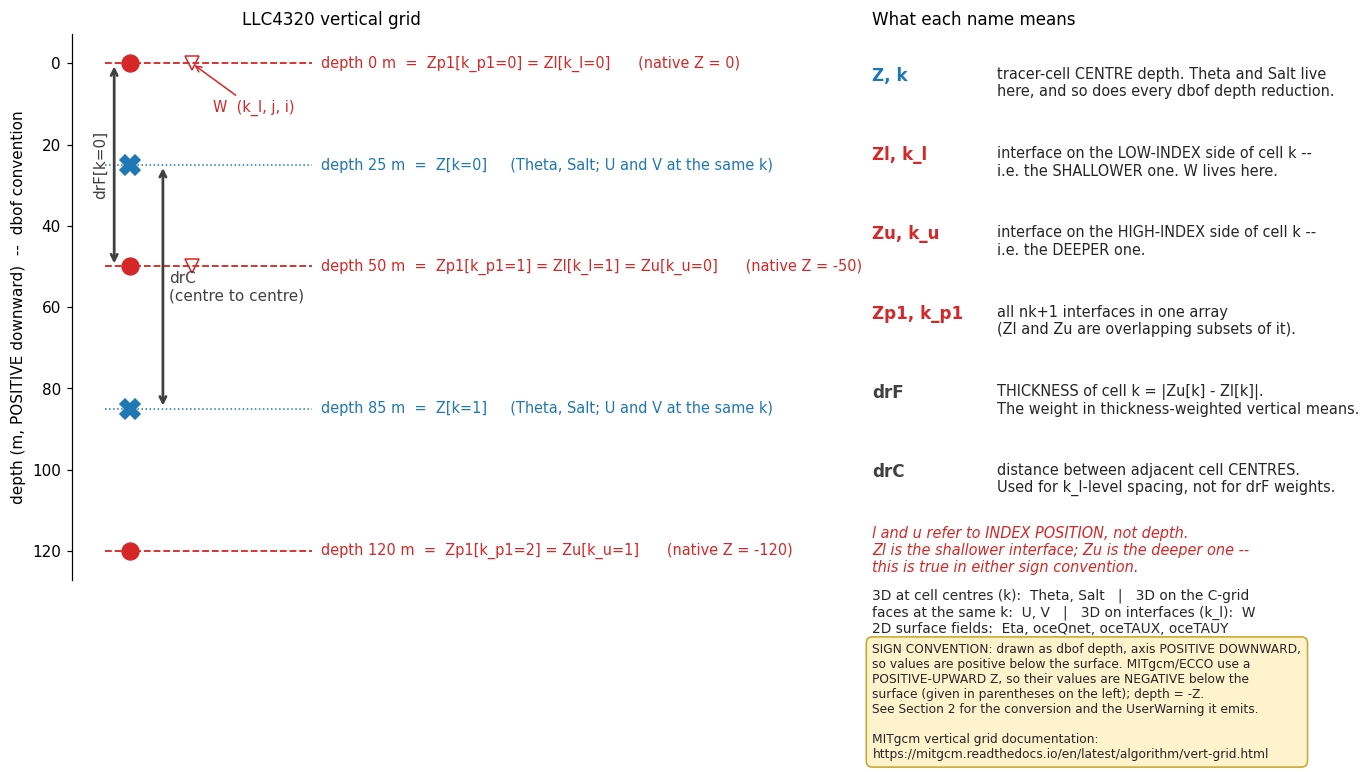

In [ ]:
ax_col, ax_key = draw_vertical_schematic()
plt.tight_layout()
plt.show()


## 1. The real LLC4320 vertical structure

The real (cached) vertical coordinates come first because everything
else refers to them. Left: the 51 tracer-cell centre depths (`|Z|`,
positive-down) against level index `k`. Right: the layer thickness
`drF` against depth — LLC4320 refines toward the surface (1.0 m cells
at the top, 46 m at the bottom of the DBOF domain). The integral
check `sum(drF) = span(Zp1)` confirms the thicknesses tile the domain
exactly.


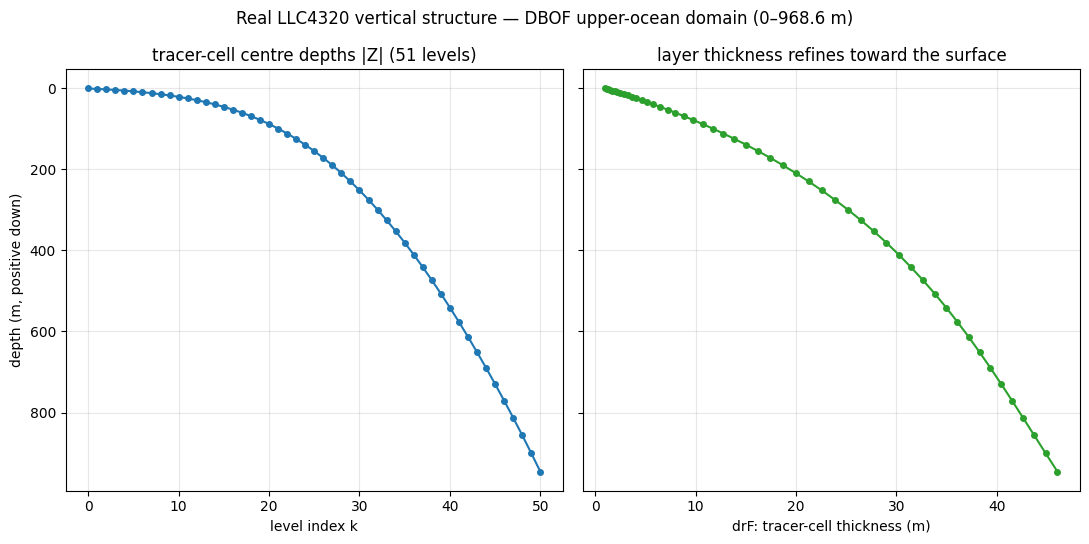

centre depths: 0.50 .. 945.6 m (51 levels)
drF: 1.00 .. 46.0 m; sum(drF) = 968.62 m vs interface span (Zp1) = 968.62 m
NOTE: ~968 m is the full DBOF vertical domain (upper-ocean subset), not a plotting limit.


In [2]:
dsr = tvh.load_real_llc_vertical()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')          # the flip warning is shown
    depth_r = vh._get_depth_coord(dsr, zdim='k').values   # in Section 2
drf_r = vh._get_vertical_spacing(dsr, zdim='k').values
k = np.arange(len(depth_r))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
axes[0].plot(k, depth_r, 'o-', ms=4)
axes[0].set_xlabel('level index k')
axes[0].set_ylabel('depth (m, positive down)')
axes[0].set_title('tracer-cell centre depths |Z| (51 levels)')
axes[1].plot(drf_r, depth_r, 'o-', ms=4, color='C2')
axes[1].set_xlabel('drF: tracer-cell thickness (m)')
axes[1].set_title('layer thickness refines toward the surface')
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].invert_yaxis()                       # depth increases downward
fig.suptitle('Real LLC4320 vertical structure — DBOF upper-ocean '
             'domain (0–968.6 m)')
fig.tight_layout()
plt.show()

span = abs(float(dsr['Zp1'].values[-1] - dsr['Zp1'].values[0]))
print(f'centre depths: {depth_r.min():.2f} .. {depth_r.max():.1f} m '
      f'(51 levels)')
print(f'drF: {drf_r.min():.2f} .. {drf_r.max():.1f} m; '
      f'sum(drF) = {drf_r.sum():.2f} m vs interface span (Zp1) = '
      f'{span:.2f} m')
print('NOTE: ~968 m is the full DBOF vertical domain (upper-ocean '
      'subset), not a plotting limit.')


## 2. Sign conversion: native `Z` (negative-up) → depth (positive-down)

`_get_depth_coord` flips the native MITgcm sign and **warns** when it
does. The demonstration below captures and prints the warning, then
shows the conversion on the real 51-level coordinate: same numbers,
opposite sign, and the order of levels is untouched (no accidental
re-sorting). The unit tests also verify a **positive** input is
returned unchanged (no double flip) and that the warning does *not*
fire in that case.


UserWarning emitted by _get_depth_coord:
  Flipping vertical coordinate 'Z' from the native MITgcm negative-upward convention to POSITIVE-DOWNWARD depth (0 at the surface, increasing with depth). All depths downstream of dbof vertical helpers use this convention.


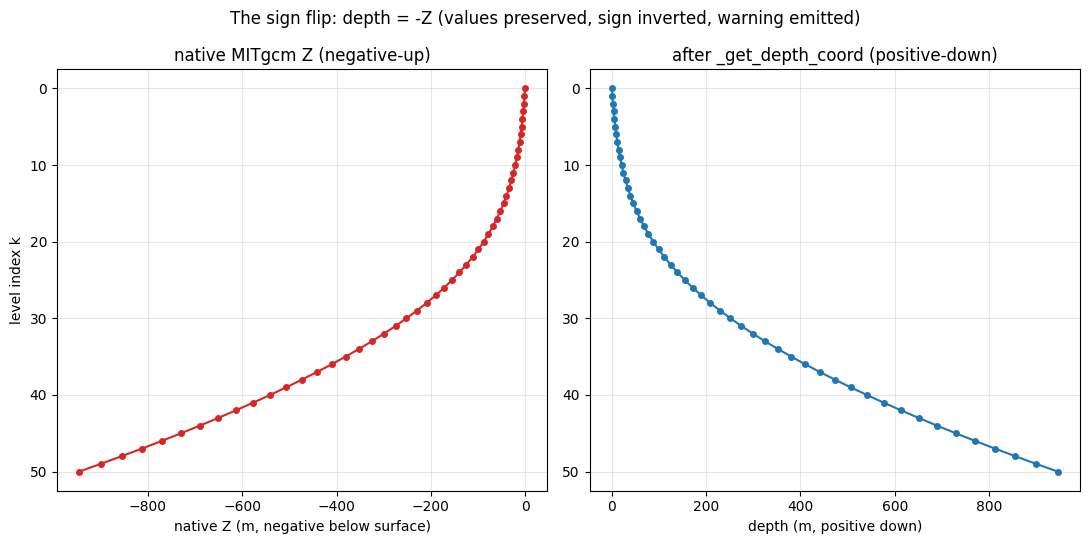

depth == -Z at every level: OK


In [3]:
# Trigger the conversion on the real Z and capture the warning it emits.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    depth = vh._get_depth_coord(dsr, zdim='k')
print('UserWarning emitted by _get_depth_coord:')
print(' ', str(caught[0].message))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].plot(dsr['Z'].values, k, 'o-', ms=4, color='C3')
axes[0].set_xlabel('native Z (m, negative below surface)')
axes[0].set_ylabel('level index k')
axes[0].invert_yaxis()
axes[0].set_title('native MITgcm Z (negative-up)')
axes[1].plot(depth.values, k, 'o-', ms=4, color='C0')
axes[1].set_xlabel('depth (m, positive down)')
axes[1].invert_yaxis()
axes[1].set_title('after _get_depth_coord (positive-down)')
for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle('The sign flip: depth = -Z (values preserved, sign '
             'inverted, warning emitted)')
fig.tight_layout()
plt.show()

np.testing.assert_allclose(depth.values, -dsr['Z'].values)
print('depth == -Z at every level: OK')


## 3. Vertical derivative of a linear profile (offline)

A linear profile `f(z) = slope · z` has derivative `slope`
everywhere; centred/forward/backward differences are all exact for it,
so `_vertical_derivative` must return the slope at every level to
machine precision. The sign convention matters physically: with depth
positive-down, a temperature that **decreases** with depth must give
`dθ/dz < 0`. Both are shown (profiles on the left, derivatives on the
right, depth on the y-axis increasing downward).


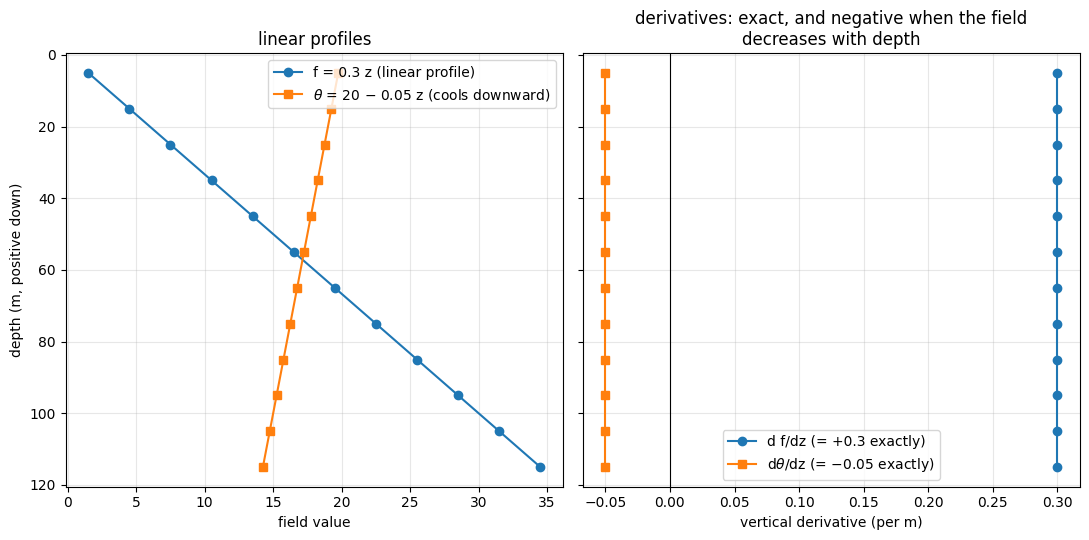

max |d f/dz − 0.3|      = 0.00e+00
max |d theta/dz + 0.05| = 0.00e+00


In [4]:
ds_syn, z_pos = tvh.make_synthetic_vertical(nk=12, dz=10.0)
slope_up = 0.3                     # f increases with depth
theta0, dtheta = 20.0, -0.05       # temperature decreasing with depth
f_up = slope_up * z_pos
theta = theta0 + dtheta * z_pos

with warnings.catch_warnings():
    warnings.simplefilter('ignore')          # flip warning shown above
    d_up = vh._vertical_derivative(tvh.vertical_field(f_up), ds_syn)
    d_th = vh._vertical_derivative(tvh.vertical_field(theta), ds_syn)
d_up_1d = d_up.isel(j=0, i=0).values
d_th_1d = d_th.isel(j=0, i=0).values

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
axes[0].plot(f_up, z_pos, 'o-', label='f = 0.3 z (linear profile)')
axes[0].plot(theta, z_pos, 's-',
             label=r'$\theta$ = 20 − 0.05 z (cools downward)')
axes[0].set_xlabel('field value')
axes[0].set_ylabel('depth (m, positive down)')
axes[0].set_title('linear profiles')
axes[0].legend()
axes[1].plot(d_up_1d, z_pos, 'o-', label='d f/dz (= +0.3 exactly)')
axes[1].plot(d_th_1d, z_pos, 's-',
             label=r'd$\theta$/dz (= −0.05 exactly)')
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel('vertical derivative (per m)')
axes[1].set_title('derivatives: exact, and negative when the field\n'
                  'decreases with depth')
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].invert_yaxis()
fig.tight_layout()
plt.show()

print(f'max |d f/dz − 0.3|      = {np.abs(d_up_1d - 0.3).max():.2e}')
print(f'max |d theta/dz + 0.05| = {np.abs(d_th_1d + 0.05).max():.2e}')


## 4. Thickness-weighted mixed-layer mean (offline)

**What `_masked_ml_mean` does:** it averages a field over the cells
whose **centre depth** lies inside the mixed layer (`depth ≤ MLD`),
weighting each cell by its thickness `drF` — i.e.

`ML mean = Σ_k f[k] · drF[k] / Σ_k drF[k]`, summed over `z_k ≤ MLD`.

Below, the profile is `f = 2 z` on 10 uniform 10 m cells with
MLD = 55 m, so cells with centres 5, 15, 25, 35, 45, 55 m are inside.
The hand computation is printed next to the helper output so the
weighting is fully transparent.


 k  centre z (m)  drF (m)  f = 2z  in ML?
 0          5.0     10.0    10.0  yes
 1         15.0     10.0    30.0  yes
 2         25.0     10.0    50.0  yes
 3         35.0     10.0    70.0  yes
 4         45.0     10.0    90.0  yes
 5         55.0     10.0   110.0  yes
 6         65.0     10.0   130.0  no
 7         75.0     10.0   150.0  no
 8         85.0     10.0   170.0  no
 9         95.0     10.0   190.0  no
hand-computed thickness-weighted mean = 60.0000
_masked_ml_mean                       = 60.0000


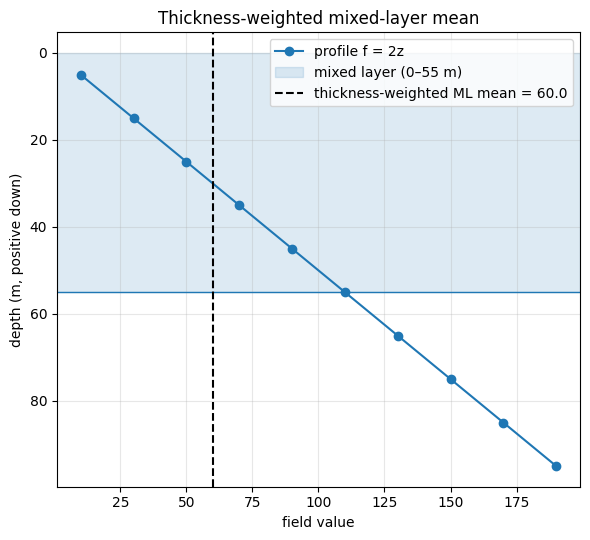

In [5]:
ds_ml, z_ml = tvh.make_synthetic_vertical(nk=10, dz=10.0, nspace=1)
prof = 2.0 * z_ml
field = tvh.vertical_field(prof, nspace=1)
mld_depth = 55.0
mld = xr.DataArray(np.full((1, 1), mld_depth), dims=('j', 'i'))
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ml_mean = float(vh._masked_ml_mean(field, mld, ds_ml)
                    .values.ravel()[0])

# Hand computation, printed row by row.
drf = ds_ml['drF'].values
in_ml = z_ml <= mld_depth
print(' k  centre z (m)  drF (m)  f = 2z  in ML?')
for kk in range(len(z_ml)):
    print(f'{kk:2d}  {z_ml[kk]:11.1f}  {drf[kk]:7.1f}  {prof[kk]:6.1f}'
          f'  {"yes" if in_ml[kk] else "no"}')
hand = np.sum(prof[in_ml] * drf[in_ml]) / np.sum(drf[in_ml])
print(f'hand-computed thickness-weighted mean = {hand:.4f}')
print(f'_masked_ml_mean                       = {ml_mean:.4f}')

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(prof, z_ml, 'o-', label='profile f = 2z')
ax.axhspan(0, mld_depth, color='C0', alpha=0.15,
           label=f'mixed layer (0–{mld_depth:.0f} m)')
ax.axhline(mld_depth, color='C0', lw=1)
ax.axvline(ml_mean, color='k', ls='--',
           label=f'thickness-weighted ML mean = {ml_mean:.1f}')
ax.set_xlabel('field value')
ax.set_ylabel('depth (m, positive down)')
ax.invert_yaxis()
ax.set_title('Thickness-weighted mixed-layer mean')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 5. Cell-centre targeting: do you end up in the middle of the cell?

`_select_at_depth` / `_nearest_k_to_depth` resolve a target depth to
the **nearest tracer-cell centre** (never an interface). The figure
shows the real 51-level grid: horizontal lines are the cell interfaces
(`Zp1`), dots are the cell centres (`|Z|`), stars are requested target
depths, and each arrow points to the centre the helper actually
selects — targets land in the middle of a cell, as the review asked to
see.

**One nearest-centre caveat** (right panel, deliberately exaggerated
non-uniform cells): a target *inside* a thick cell but very close to
its upper interface can resolve to the **thin cell above**, because
that cell's centre is nearer (15 m lies inside the 14–30 m cell, but
is closer to the 10 m centre than to the 22 m centre). This is the
documented nearest-CENTRE semantics, tested in
`test_select_at_depth_targets_cell_centres`.


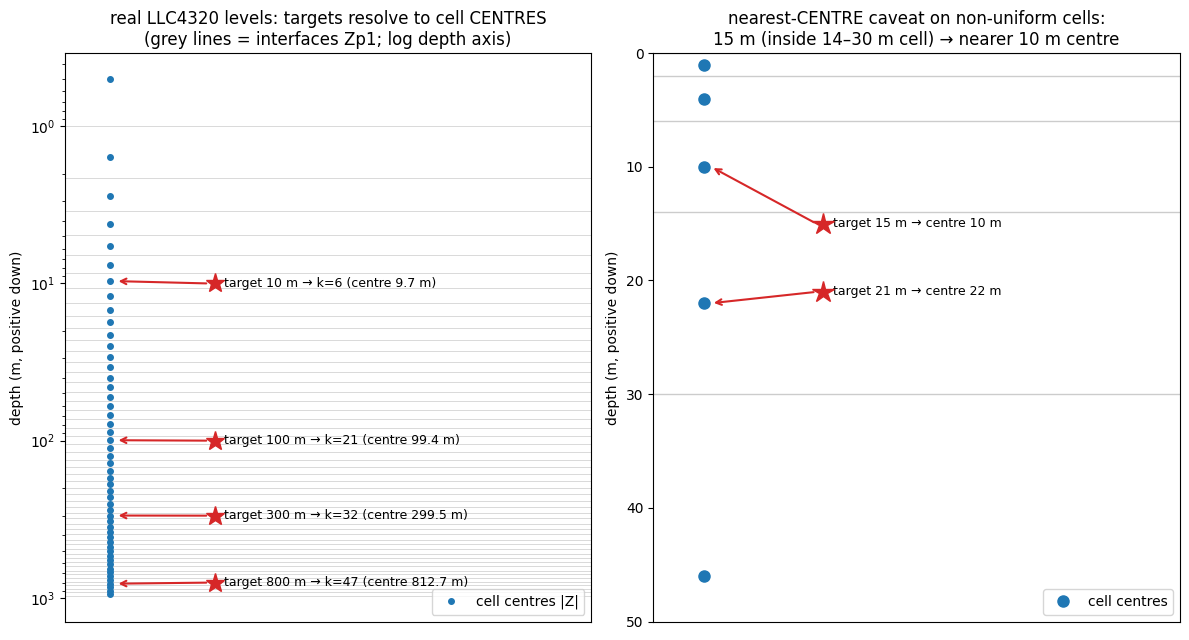

In [6]:
iface_r = np.abs(dsr['Zp1'].values)          # real interfaces (pos-down)
targets_r = [10.0, 100.0, 300.0, 800.0]

drf_syn = [2.0, 4.0, 8.0, 16.0, 32.0]
ds_tgt, z_tgt = tvh.make_synthetic_vertical(nk=5, drf=drf_syn)
iface_s = np.concatenate([[0.0], np.cumsum(drf_syn)])
targets_s = [15.0, 21.0]                     # the near-interface caveat

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))

ax = axes[0]
for zi in iface_r:
    ax.axhline(zi, color='0.85', lw=0.7, zorder=1)
ax.plot(np.zeros_like(depth_r), depth_r, 'o', ms=4, color='C0',
        zorder=3, label='cell centres |Z|')
for t in targets_r:
    ksel = vh._nearest_k_to_depth(depth_r, t)
    ax.plot(0.35, t, '*', ms=14, color='C3', zorder=4)
    ax.annotate('', xy=(0.02, depth_r[ksel]), xytext=(0.33, t),
                arrowprops=dict(arrowstyle='->', color='C3', lw=1.5))
    ax.text(0.38, t, f'target {t:.0f} m → k={ksel} '
            f'(centre {depth_r[ksel]:.1f} m)', va='center', fontsize=9)
ax.set_xlim(-0.15, 1.6)
ax.set_xticks([])
ax.set_ylabel('depth (m, positive down)')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_title('real LLC4320 levels: targets resolve to cell CENTRES\n'
             '(grey lines = interfaces Zp1; log depth axis)')
ax.legend(loc='lower right')

ax = axes[1]
for zi in iface_s:
    ax.axhline(zi, color='0.8', lw=1, zorder=1)
ax.plot(np.zeros_like(z_tgt), z_tgt, 'o', ms=8, color='C0', zorder=3,
        label='cell centres')
for t in targets_s:
    ksel = vh._nearest_k_to_depth(z_tgt, t)
    ax.plot(0.35, t, '*', ms=16, color='C3', zorder=4)
    ax.annotate('', xy=(0.02, z_tgt[ksel]), xytext=(0.33, t),
                arrowprops=dict(arrowstyle='->', color='C3', lw=1.5))
    ax.text(0.38, t, f'target {t:.0f} m → centre {z_tgt[ksel]:.0f} m',
            va='center', fontsize=9)
ax.set_xlim(-0.15, 1.4)
ax.set_xticks([])
ax.set_ylim(0, 50)
ax.invert_yaxis()
ax.set_ylabel('depth (m, positive down)')
ax.set_title('nearest-CENTRE caveat on non-uniform cells:\n'
             '15 m (inside 14–30 m cell) → nearer 10 m centre')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()


## 6. Vertical derivative on the real non-uniform levels (online)

Same linear-profile check as Section 3, but on the genuine non-uniform
LLC4320 spacing (1.0 m cells at the surface, 46 m at depth): the
difference stencils are exact for a linear field regardless of the
spacing, so the recovered derivative is the prescribed slope at all 51
levels.


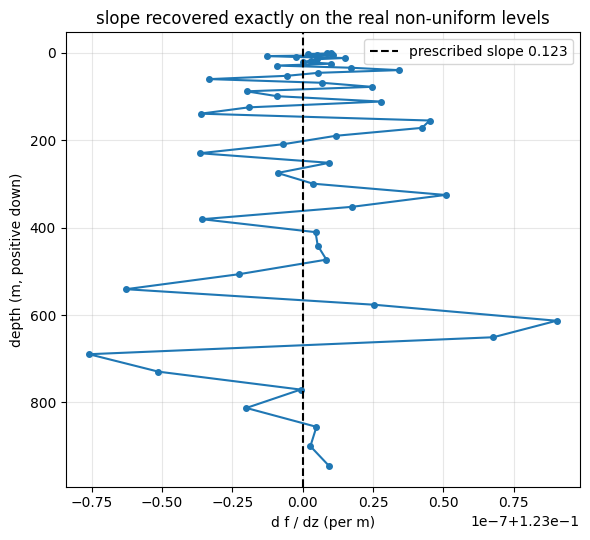

max |deriv − slope| = 9.03e-08


In [7]:
slope = 0.123
field_r = tvh.vertical_field(slope * depth_r)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    deriv_r = vh._vertical_derivative(field_r, dsr)
d1 = deriv_r.isel(j=0, i=0).values

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(d1, depth_r, 'o-', ms=4)
ax.axvline(slope, color='k', ls='--', label=f'prescribed slope {slope}')
ax.set_xlabel('d f / dz (per m)')
ax.set_ylabel('depth (m, positive down)')
ax.invert_yaxis()
ax.set_title('slope recovered exactly on the real non-uniform levels')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print(f'max |deriv − slope| = {np.abs(d1 - slope).max():.2e}')


## 7. Run the test suite

Runs every offline test and (because the tiny vertical cache is
available) the three online tests, exactly as `pytest` would.


In [8]:
offline = [
    tvh.test_get_vertical_dim_detection,
    tvh.test_depth_coord_sign_conversion,
    tvh.test_depth_coord_flip_emits_warning,
    tvh.test_depth_coord_already_positive_is_unchanged,
    tvh.test_depth_coord_renames_Z_dimension,
    tvh.test_depth_coord_kl_uses_Zl,
    tvh.test_vertical_spacing_uses_drF_for_tracer_levels,
    tvh.test_vertical_spacing_fallback_to_gradient,
    tvh.test_nearest_k_to_depth,
    tvh.test_select_at_depth_targets_cell_centres,
    tvh.test_vertical_derivative_linear_is_exact,
    tvh.test_vertical_derivative_sign_decreasing_with_depth,
    tvh.test_select_at_depth_picks_nearest_level,
    tvh.test_extract_at_mld_per_column,
    tvh.test_interp_w_to_tracer_levels_averages_interfaces,
    tvh.test_masked_ml_mean_constant_field,
    tvh.test_masked_ml_mean_thickness_weighted,
]
online = [
    tvh.test_real_depth_coord_sign_and_monotonic,
    tvh.test_real_vertical_spacing_drF_consistent,
    tvh.test_real_vertical_derivative_linear_exact,
]
with warnings.catch_warnings():
    warnings.simplefilter('ignore')          # flip warnings shown above
    for t in offline:
        t()
    print(f'{len(offline)} offline tests passed.')
    for t in online:
        t()
    print(f'{len(online)} online tests passed.')


17 offline tests passed.
3 online tests passed.
